In [4]:
%pwd

'/content'

In [5]:
!pip install -q python-dotenv

from dotenv import load_dotenv
import os

load_dotenv()  # automatically finds .env in the current directory

os.environ['KAGGLE_USERNAME'] = os.getenv('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = os.getenv('KAGGLE_KEY')

print("Loaded username:", os.environ['KAGGLE_USERNAME'])

Loaded username: ashwiniambastha


In [6]:
''''' !kaggle datasets download -d khaledhellmy/brain-breast-tumor
!unzip -q brain-breast-tumor.zip -d brain-breast-tumor '''''

"'' !kaggle datasets download -d khaledhellmy/brain-breast-tumor\n!unzip -q brain-breast-tumor.zip -d brain-breast-tumor "

In [7]:

'''''
# 2. Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Install kaggle (usually already present, but safe to run)
!pip install -q kaggle

# 4. Download the dataset
!kaggle datasets download -d khaledhellmy/brain-breast-tumor

# 5. Unzip it
!unzip -q brain-breast-tumor.zip -d brain-breast-tumor

# 6. Check what's inside
!ls brain-breast-tumor '''''

"''\n# 2. Set up Kaggle credentials\n!mkdir -p ~/.kaggle\n!cp kaggle.json ~/.kaggle/\n!chmod 600 ~/.kaggle/kaggle.json\n\n# 3. Install kaggle (usually already present, but safe to run)\n!pip install -q kaggle\n\n# 4. Download the dataset\n!kaggle datasets download -d khaledhellmy/brain-breast-tumor\n\n# 5. Unzip it\n!unzip -q brain-breast-tumor.zip -d brain-breast-tumor\n\n# 6. Check what's inside\n!ls brain-breast-tumor "

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/brain-breast-tumor/Dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y749.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y738.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y783.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y761.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y776.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y716.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y779.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y774.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y739.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y722.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y704.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y732.png
/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST_masks/y771.png
/content/brain-breast-tumor/Dataset/Br

In [9]:
print("Data Downloaded")

Data Downloaded


In [10]:
import pandas as pd
import os

base_paths = [
    ("/content/brain-breast-tumor/Dataset/Brain scans/No tumor/Train", "No tumor", "Train"),
    ("/content/brain-breast-tumor/Dataset/Brain scans/No tumor/Test", "No tumor", "Test"),
    ("/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TRAIN", "Tumor", "Train"),
    ("/content/brain-breast-tumor/Dataset/Brain scans/Tumor/TEST", "Tumor", "Test"),
    ("/content/brain-breast-tumor/Dataset/Breast scans/benign/Train", "benign", "Train"),
    ("/content/brain-breast-tumor/Dataset/Breast scans/benign/Test", "benign" , "Test"),
    ("/content/brain-breast-tumor/Dataset/Breast scans/malignant/Train", "malignant", "Train"),
    ("/content/brain-breast-tumor/Dataset/Breast scans/malignant/Test", "malignant", "Test"),
    ("/content/brain-breast-tumor/Dataset/Breast scans/normal/Train", "normal", "Train"),
    ("/content/brain-breast-tumor/Dataset/Breast scans/normal/Test", "normal", "Test")
]

def collect_image_data():
    image_paths = []
    labels = []
    splits = []
    for path, label, split in base_paths:
        if not os.path.exists(path):
            print(f"Warning: Directory {path} does not exist.")
            continue
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            if os.path.isfile(img_path) and img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(img_path)
                labels.append(label)
                splits.append(split)
    return image_paths, labels, splits

image_paths, labels, splits = collect_image_data()

df = pd.DataFrame({
    'Image_Path': image_paths,
    'Label': labels,
    'Split': splits
})

In [11]:
df

,Image_Path,Label,Split
0,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor,Train
1,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor,Train
2,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor,Train
3,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor,Train
4,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor,Train
...,...,...,...
2640,/content/brain-breast-tumor/Dataset/Breast sca...,normal,Test
2641,/content/brain-breast-tumor/Dataset/Breast sca...,normal,Test
2642,/content/brain-breast-tumor/Dataset/Breast sca...,normal,Test
2643,/content/brain-breast-tumor/Dataset/Breast sca...,normal,Test


In [12]:
df = df[['Image_Path', 'Label']]

In [13]:
df

,Image_Path,Label
0,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
1,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
2,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
3,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
4,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
...,...,...
2640,/content/brain-breast-tumor/Dataset/Breast sca...,normal
2641,/content/brain-breast-tumor/Dataset/Breast sca...,normal
2642,/content/brain-breast-tumor/Dataset/Breast sca...,normal
2643,/content/brain-breast-tumor/Dataset/Breast sca...,normal


EDA - EXPLORATORY DATA ANALYSIS

In [14]:
df.shape

(2645, 2)

In [15]:
df.columns

Index(['Image_Path', 'Label'], dtype='object')

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.isnull().sum()

,0
Image_Path,0
Label,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  2645 non-null   object
 1   Label       2645 non-null   object
dtypes: object(2)
memory usage: 41.5+ KB


In [19]:
df['Label'].unique()

array(['No tumor', 'Tumor', 'benign', 'malignant', 'normal'], dtype=object)

'No tumor', 'Tumor', 'benign', 'malignant', 'normal'

MULTI CLASS CLASSIFICATION

CHECK COUNT 

In [20]:
df['Label'].value_counts()

,count
Label,
benign,891
No tumor,601
Tumor,600
malignant,420
normal,133


/tmp/ipykernel_4433/2624861623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Label", palette="viridis", ax=ax)


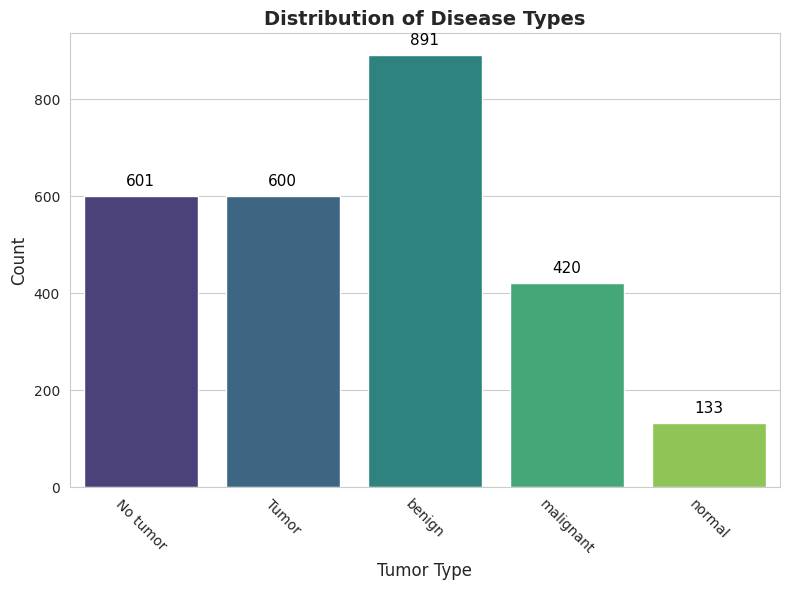

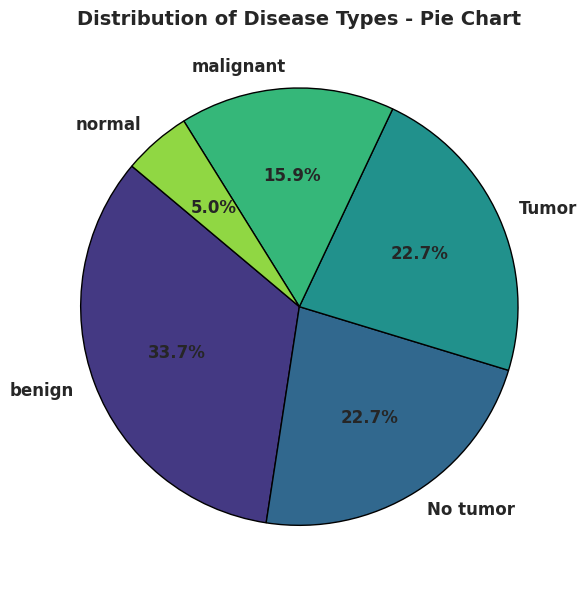

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="Label", palette="viridis", ax=ax)
ax.set_title("Distribution of Disease Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.xticks(rotation=-45)
plt.tight_layout()
plt.show()

label_counts = df["Label"].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))
ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})
ax.set_title("Distribution of Disease Types - Pie Chart", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

VISUALIZE THE IMAGES

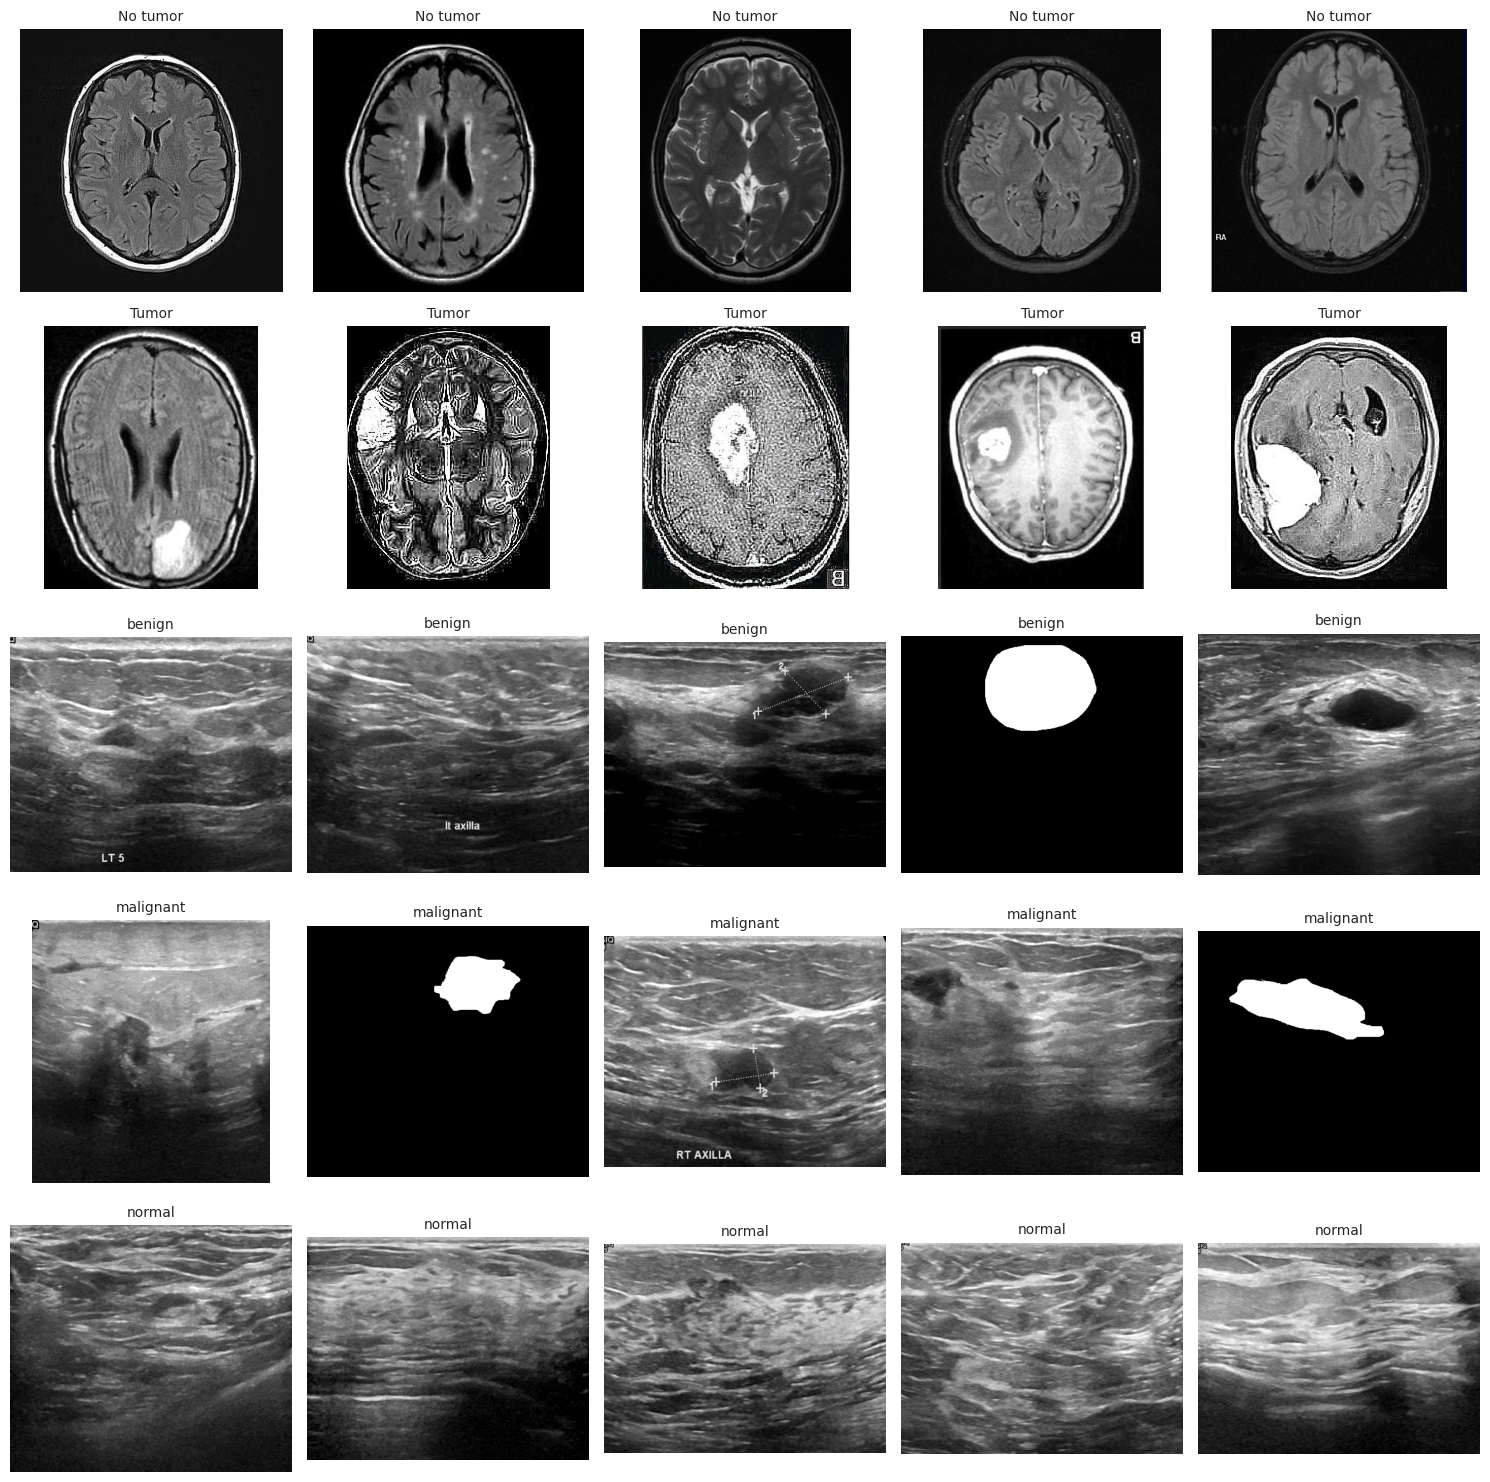

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2

categories = df['Label'].unique()

n_cols = 5
n_rows = len(categories)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
if n_rows == 1:
    axes = [axes]
else:
    axes = axes.flatten()

plot_idx = 0

for category in categories:
    category_paths = df[df['Label'] == category]['Image_Path'].head(5).tolist()
    
    for img_path in category_paths:
        if plot_idx < len(axes):
            try:
                img = cv2.imread(img_path)
                if img is None:
                    axes[plot_idx].text(0.5, 0.5, 'Image not found', 
                                        ha='center', va='center', transform=axes[plot_idx].transAxes)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[plot_idx].imshow(img)
                axes[plot_idx].set_title(category, fontsize=10)
                axes[plot_idx].axis('off')
            except:
                axes[plot_idx].text(0.5, 0.5, 'Error loading', 
                                    ha='center', va='center', transform=axes[plot_idx].transAxes)
            plot_idx += 1
    
    while len(category_paths) < 5 and plot_idx < len(axes):
        axes[plot_idx].text(0.5, 0.5, 'No image', 
                            ha='center', va='center', transform=axes[plot_idx].transAxes)
        axes[plot_idx].set_title(category, fontsize=10)
        axes[plot_idx].axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

BALANCING THE DATA

In [23]:
from sklearn.utils import resample

categories = df['Label'].unique()

max_count = df['Label'].value_counts().max()

df_balanced = pd.DataFrame()

for category in categories:
    df_category = df[df['Label'] == category]
    df_category_resampled = resample(df_category, 
                                    replace=True, 
                                    n_samples=max_count, 
                                    random_state=42)
    df_balanced = pd.concat([df_balanced, df_category_resampled], ignore_index=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Label'].value_counts())

df = df_balanced

Label
malignant    891
No tumor     891
Tumor        891
normal       891
benign       891
Name: count, dtype: int64


In [24]:
df

,Image_Path,Label
0,/content/brain-breast-tumor/Dataset/Breast sca...,malignant
1,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
2,/content/brain-breast-tumor/Dataset/Brain scan...,Tumor
3,/content/brain-breast-tumor/Dataset/Brain scan...,Tumor
4,/content/brain-breast-tumor/Dataset/Breast sca...,normal
...,...,...
4450,/content/brain-breast-tumor/Dataset/Breast sca...,normal
4451,/content/brain-breast-tumor/Dataset/Brain scan...,No tumor
4452,/content/brain-breast-tumor/Dataset/Breast sca...,malignant
4453,/content/brain-breast-tumor/Dataset/Breast sca...,normal


MODEL TRAINING 

BASELINE CNN MODEL

In [25]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [26]:
IMG_SIZE = 128

def load_images(df):
    X = []
    for path in df["Image_Path"]:
        img = cv2.imread(path)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0
        X.append(img)
    return np.array(X)

In [27]:
X = load_images(df)

# one hot encoding labels
y = pd.get_dummies(df["Label"]).values
label_names = pd.get_dummies(df["Label"]).columns


In [28]:
#train-test split 
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [29]:
print(X_train.shape)
print(y_train.shape)

(3564, 128, 128, 3)
(3564, 5)


In [30]:
print(X_test.shape)
print(y_test.shape)




(891, 128, 128, 3)
(891, 5)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [32]:
cnn_model = Sequential([
    
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    
    Dense(len(label_names),activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    X_train,y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.6192 - loss: 0.9000 - val_accuracy: 0.7194 - val_loss: 0.6038
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7632 - loss: 0.5779 - val_accuracy: 0.8732 - val_loss: 0.3694
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8510 - loss: 0.3775 - val_accuracy: 0.8967 - val_loss: 0.2875
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8920 - loss: 0.2848 - val_accuracy: 0.9001 - val_loss: 0.2456
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9352 - loss: 0.1910 - val_accuracy: 0.9394 - val_loss: 0.1783
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9537 - loss: 0.1359 - val_accuracy: 0.9473 - val_loss: 0.1612
Epoch 7/10
 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9575 - loss: 0.1212

In [ ]:
import os
os.makedirs("/content/brain-breast-tumor/saved-model", exist_ok=True)

In [ ]:
cnn_model.save("/content/brain-breast-tumor/saved-model/baseline_cnn.keras")
cnn_model.save("/content/brain-breast-tumor/saved-model/baseline_cnn.h5")

FileNotFoundError: [Errno 2] No such file or directory: '/content/brain-breast-tumor/saved-model/baseline_cnn.keras'

EVALUATION 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, history, model_name):
    
    print(f"\n{'='*40}")
    print(f"Evaluating {model_name}")
    print(f"{'='*40}")

    # ------------------ Accuracy & Loss Graph ------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{model_name} Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{model_name} Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # ------------------ Predictions ------------------
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    # ------------------ Confusion Matrix ------------------
    cm = confusion_matrix(y_test_classes, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)
    
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ------------------ Classification Report ------------------
    print(f"\n{model_name} Classification Report:\n")
    print(classification_report(y_test_classes, y_pred_classes, target_names=label_names))


Evaluating Baseline CNN Model


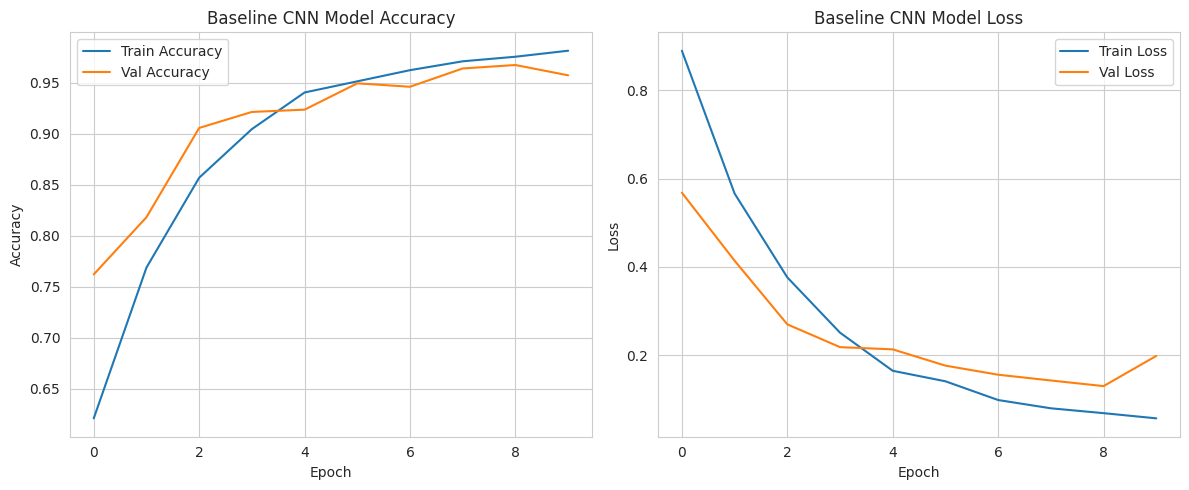

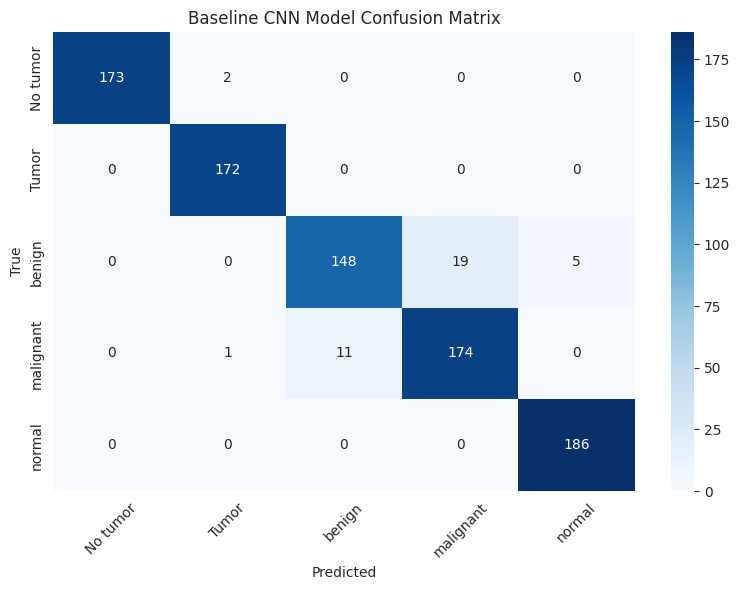


Baseline CNN Model Classification Report:

              precision    recall  f1-score   support

    No tumor       1.00      0.99      0.99       175
       Tumor       0.98      1.00      0.99       172
      benign       0.93      0.86      0.89       172
   malignant       0.90      0.94      0.92       186
      normal       0.97      1.00      0.99       186

    accuracy                           0.96       891
   macro avg       0.96      0.96      0.96       891
weighted avg       0.96      0.96      0.96       891



In [ ]:
evaluate_model(cnn_model, cnn_history, "Baseline CNN Model")

RESNET

TRANSFER LEARNING

In [ ]:
#RESNET50 TRANSFER LEARNING

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense,Flatten,GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# freeze base model
for layer in base_model.layers:
    layer.trainable=False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)

In [ ]:
outputs = Dense(len(label_names),activation='softmax')(x)

In [ ]:
resnet_model = Model(inputs=base_model.input,outputs=outputs)

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_history = resnet_model.fit(
    X_train,y_train,
    epochs=8,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 180ms/step - accuracy: 0.4380 - loss: 1.2784 - val_accuracy: 0.6554 - val_loss: 1.0295
Epoch 2/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5783 - loss: 0.9861 - val_accuracy: 0.6790 - val_loss: 0.8822
Epoch 3/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.6313 - loss: 0.8690 - val_accuracy: 0.6925 - val_loss: 0.7935
Epoch 4/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6571 - loss: 0.8069 - val_accuracy: 0.7003 - val_loss: 0.7424
Epoch 5/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6698 - loss: 0.7722 - val_accuracy: 0.6801 - val_loss: 0.7158
Epoch 6/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.6846 - loss: 0.7313 - val_accuracy: 0.7598 - val_loss: 0.6865
Epoch 7/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6902 - loss: 0.7173 - val_accuracy: 0.7250 - val_loss: 0.6664
Epoch 8/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7037 - loss: 0.6874 - val_accuracy: 

In [ ]:
resnet_model.save("/content/brain-breast-tumor/saved-model/resnet_model.keras")
resnet_model.save("/content/brain-breast-tumor/saved-model/resnet_model.h5")


Evaluating ResNet50 Model


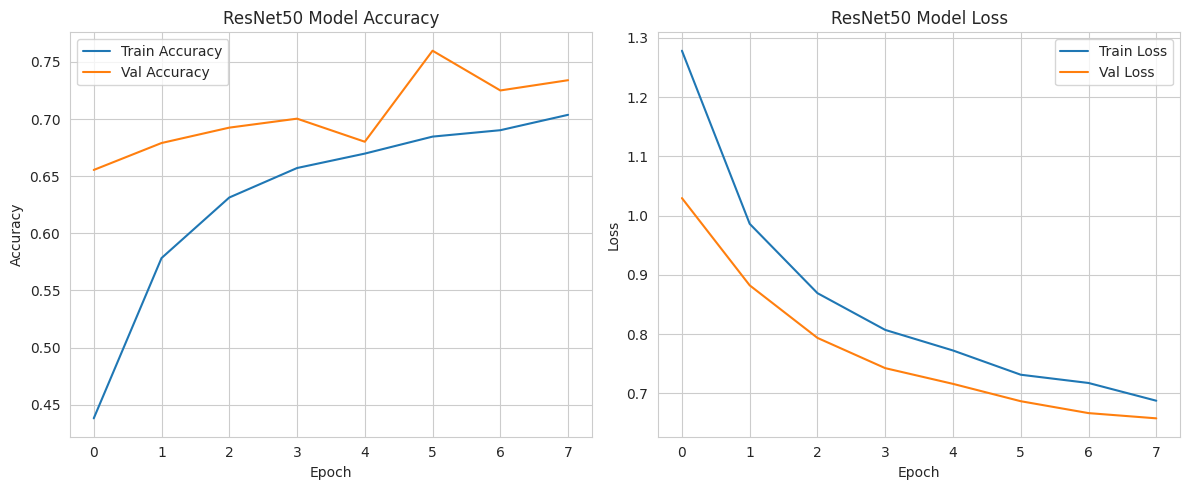

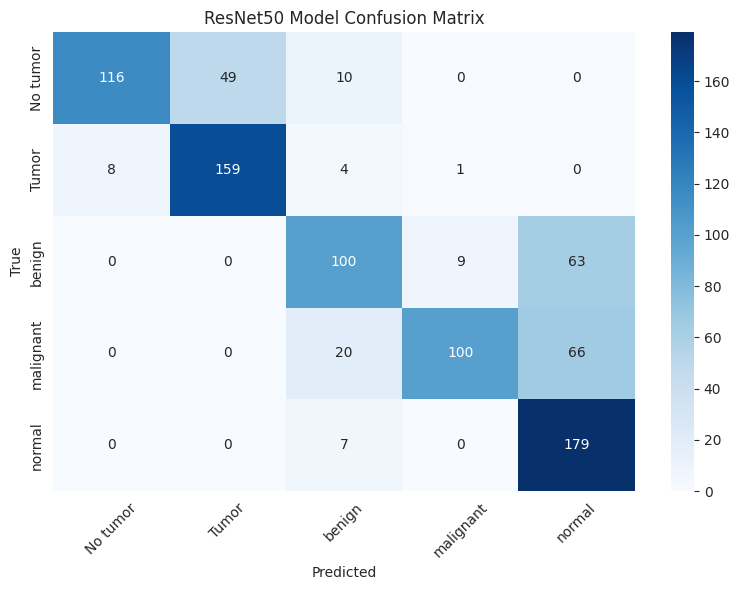


ResNet50 Model Classification Report:

              precision    recall  f1-score   support

    No tumor       0.94      0.66      0.78       175
       Tumor       0.76      0.92      0.84       172
      benign       0.71      0.58      0.64       172
   malignant       0.91      0.54      0.68       186
      normal       0.58      0.96      0.72       186

    accuracy                           0.73       891
   macro avg       0.78      0.73      0.73       891
weighted avg       0.78      0.73      0.73       891



In [ ]:
evaluate_model(resnet_model, resnet_history, "ResNet50 Model")

CUSTOM TRIGNOMETRIC FILTER CNN

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense, Flatten
from tensorflow.keras.models import Model
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class TrigConv2D(Layer):
    def __init__(self, filters, kernel_size, frequency=1.0, **kwargs):
        super(TrigConv2D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.frequency = frequency

    def build(self, input_shape):
        kernel_shape = (self.kernel_size, self.kernel_size, input_shape[-1], self.filters)
        kernels = []
        for i in range(self.filters):
            x = np.linspace(-1, 1, self.kernel_size)
            y = np.linspace(-1, 1, self.kernel_size)
            x_grid, y_grid = np.meshgrid(x, y)
            if i % 2 == 0:
                kernel = np.sin(self.frequency * (x_grid + y_grid))
            else:
                kernel = np.cos(self.frequency * (x_grid + y_grid))
            kernel = kernel[:, :, np.newaxis, np.newaxis]
            kernel = np.repeat(kernel, input_shape[-1], axis=2)
            kernel = np.repeat(kernel, 1, axis=3)
            kernels.append(kernel)
        self.kernel = tf.constant(np.concatenate(kernels, axis=3), dtype=tf.float32)
        super(TrigConv2D, self).build(input_shape)

    def call(self, inputs):
        return tf.nn.conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

In [ ]:
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    img = cv2.imread(image_path)
    if img is None:
        return np.zeros((*target_size, 3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    return img

In [ ]:
image_size = (128, 128)
X = np.array([load_and_preprocess_image(path, image_size) for path in df['Image_Path']])
y = pd.get_dummies(df['Label']).values
label_names = pd.get_dummies(df['Label']).columns


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
inputs = Input(shape=(image_size[0], image_size[1], 3))
x = TrigConv2D(filters=16, kernel_size=3, frequency=2.0)(inputs)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(len(label_names), activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6989 - loss: 0.8393 - val_accuracy: 0.8395 - val_loss: 0.4398
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9282 - loss: 0.2267 - val_accuracy: 0.8956 - val_loss: 0.2694
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9820 - loss: 0.0724 - val_accuracy: 0.9630 - val_loss: 0.1156
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9919 - loss: 0.0482 - val_accuracy: 0.9675 - val_loss: 0.1102
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9983 - loss: 0.0150 - val_accuracy: 0.9562 - val_loss: 0.1275
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9961 - loss: 0.0206 - val_accuracy: 0.8923 - val_loss: 0.3448
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9952 - loss: 0.0239 - val_accuracy: 0.9641 - val_loss: 0.1242
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accu

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=label_names))

: 

In [ ]:
model.save("/content/brain-breast-tumor/saved-model/trig_model.keras")
model.save("/content/brain-breast-tumor/saved-model/trig_model.h5")

WRITE A BETTER NEURAL NETWORK SOLVING THE DRAWBACKS OF THIS NEURAL NETWORK

GRAD CAM

In [ ]:
#GradCAM implementation 
#Function to generate GradCAM
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam(model, image, conv2d, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(conv2d).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.array([image]))
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
            
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
#Superimpose heatmap on image
def display_gradcam(img, heatmap, alpha=0.4):
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    
    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM Visualization")
    plt.show()

In [ ]:
#Test GradCAM on sample image
idx = 10   # change index
sample_image = X_test[idx]
true_label = np.argmax(y_test[idx])

pred = model.predict(np.array([sample_image]))
pred_class = np.argmax(pred)

print("True label:", label_names[true_label])
print("Predicted:", label_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
True label: benign
Predicted: benign


In [ ]:
heatmap = get_gradcam(model, sample_image, "conv2d")
display_gradcam((sample_image*255).astype("uint8"), heatmap)

ValueError: No such layer: conv2d. Existing layers are: ['input_layer_2', 'trig_conv2d', 'activation', 'max_pooling2d_3', 'conv2d_3', 'max_pooling2d_4', 'flatten_1', 'dense_4', 'dense_5'].